# "Winter" Data Workout: Exploratory Analysis and Modeling

In this workout, you have the choice between 1 of 2 "Winter" datasets:

* Penguins
* Winter Olympics

## Dataset Overview: Palmer Penguins

![Two Penguins](../images/stock/pexels-pixabay-48814.jpg)

The penguins dataset contains size measurements for three penguin species observed in the Palmer Archipelago, Antarctica. It was collected by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER.

### Location
* __Seaborn__: The dataset may be accessed via `sns.load_dataset("penguins")`

### __Key Features (Columns)__:
* __species__: The penguin species (Adélie, Chinstrap, or Gentoo).

* __island__: The island in the Palmer Archipelago where the penguin was observed (Biscoe, Dream, or Torgersen).

* __bill_length_mm__: The length of the penguin's bill (also known as the culmen) in millimeters.

* __bill_depth_mm__: The depth of the penguin's bill in millimeters.

* __flipper_length_mm__: The length of the penguin's flipper in millimeters.

* __body_mass_g__: The body mass of the penguin in grams.

* __sex__: The gender of the penguin (male or female).

### __Why it’s great for this workout__:
* __Classification__: Can you predict the species based on physical measurements?

* __Regression__: Can you predict body mass using flipper length?

## Dataset Overview: Olympics

![Winter Olympics](../images/stock/pexels-kimmo-vainio-314143536-36080375.jpg)

Source: [Keith Galli's Olympics Dataset](https://github.com/KeithGalli/Olympics-Dataset)

This is a comprehensive historical record of every athlete and their performance. Because it is split across two files, merging them using the `athlete_id` column will be necessary.

### Folder Location
* `../data/winter_olympics`

### __Key Data Files__:
* `bios.csv`: Biographical details for over 70,000 athletes.

* `results.csv`: A row-by-row breakdown of every event performance (over 160,000 rows).

### __Key Features (`bios.csv`)__:
* __athlete_id__: Unique athlete identifier.
  
* __name__: The athlete's full name.

* __height_cm__: In centimeters (expect many missing values!).

* __weight_kg__: In kilograms (expect many missing values!).

* __NOC__: The 3-letter country code (e.g., USA, NOR, GER).

### __Key Feature (`results.csv`)__:
* __year__: The year of the Olympic Games (1896–2022).

* __type__: The season (you should filter for "Winter").

* __discipline__: The sport (Alpine Skiing, Ice Hockey).

* __event__: The specific competition (Men's 500 metres).


### __Why it’s great for this challenge__:
* __Classification__: Can you predict if an athlete will win a medal based on their age, height, and weight?

* __Regression__: Can you predict an athlete's height or weight based on the sport they compete in?

* __Data Wrangling__: This dataset is "messy." Filtering for the Winter season and deciding how to handle missing physical stats for athletes from the early 20th century will be a unique challenge.

## Goals Checklist
![Curling](../images/stock/pexels-shvets-production-7544435.jpg)
### 1. __Data Foundations__
*  __Load the Data__: Successfully import the dataset (penguins or winter olympics).
*  __Initial Exploration__: Use `.info()`, `.describe()`, and `.head()` or `.sample()` to understand your features.
*  __Data Cleaning__: Handle missing values (drop vs. fill) and fix any data type inconsistencies.

### 2. __Visual Analysis__
*  __Feature Distributions__: Create histograms for all numerical columns.
*  __Correlation Matrix__: Generate a heatmap to identify relationships between variables.
*  __Custom Insights__: Create at least 3 additional unique visualizations.

### 3. __Machine Learning Pipeline__
*  __ML Prep__: Define your target variable ($y$) and features ($X$)
*  __Train/Test Split__: Divide your data (typically 80/20 or 70/30) to ensure unbiased evaluation.
*  __Build Model__: Initialize and fit your chosen model.
*  __Make Predictions__: Run your model on the test set.

### 4. __Evaluation & Reflection__
*  __Quantitative Evaluation__: Calculate relevant metrics.
*  __Visual Performance__: Plot your results
*  __Conclusion__: Write a brief summary of what the model tells us about the data.

In [1]:
## imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

## Penguin Exploration

Let's take a look at the dataset 👀

In [2]:
# Load Penguin Data
penguins = sns.load_dataset("penguins")

penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## Initial Inspection

The dataset contains a few missing values. Let's go ahead and drop the null rows.

In [3]:
# clean up dataset
penguins_clean = penguins.copy()

penguins_clean = penguins_clean.dropna()

penguins_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


## Statistical Data

Taking a look at the statistical data.

In [4]:
## View Statistical Data
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


## Previewing the Data

Taking a look at 10 random rows...I'm not a Biologist but I can gather that Penguins are from 3 different islands and they come in a variety shapes and sizes.

And judging from the samples, the Gentoo appear to be the most massive penguins in the set.

In [5]:
## Sample Rows
penguins_clean.sample(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
232,Gentoo,Biscoe,45.5,13.7,214.0,4650.0,Female
46,Adelie,Dream,41.1,19.0,182.0,3425.0,Male
298,Gentoo,Biscoe,45.2,13.8,215.0,4750.0,Female
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,Male
38,Adelie,Dream,37.6,19.3,181.0,3300.0,Female
308,Gentoo,Biscoe,47.5,14.0,212.0,4875.0,Female
178,Chinstrap,Dream,50.5,18.4,200.0,3400.0,Female
269,Gentoo,Biscoe,45.2,15.8,215.0,5300.0,Male
81,Adelie,Torgersen,42.9,17.6,196.0,4700.0,Male


## Numerical Distribution

The end goal is to build a predictive model based on the data.

Based on the numerical distribution, body mass, bill length, and bill depth are pretty close to a normal distribution. These features should work well with a predictive model.

Text(0.5, 0.98, 'Distribution of Numeric Data')

<Figure size 700x400 with 0 Axes>

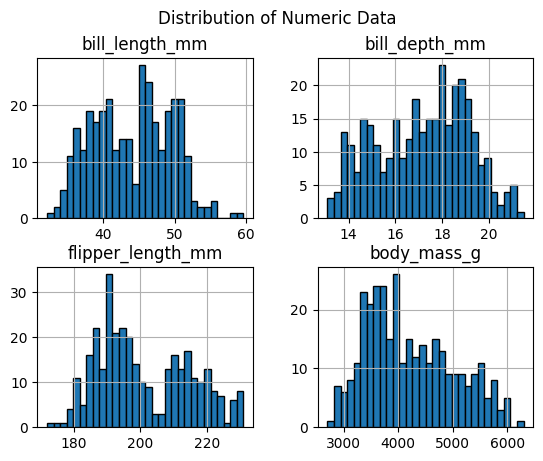

In [6]:
## Distribution of Numerical Data
plt.figure(
    figsize=(7,4)
)

penguins_clean.hist(
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numeric Data")

## Correlations

Text(0.5, 1.0, 'Penguin Feature Correlations')

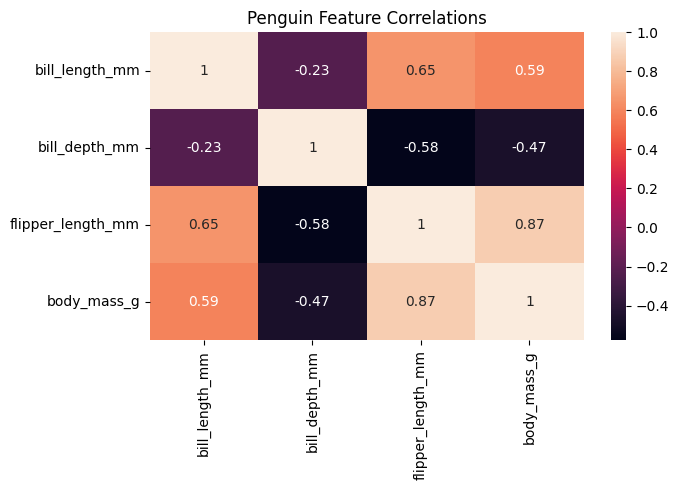

In [7]:
## Correlation Matrix
correlation_matrix = penguins_clean.corr(numeric_only=True)

plt.figure(
    figsize=(7,4)
)

sns.heatmap(
    data=correlation_matrix,
    annot=True
)

plt.title("Penguin Feature Correlations")

According to the correlation matrix

* body mass and flipper length have a strong correlation!
* flipper length and bill length have a promising correlation
* body mass and bill length have a promising correlation as well

I will make the assumption that these features will be important for the model.

## Where are the Penguins From?

Text(0.5, 0, 'Island')

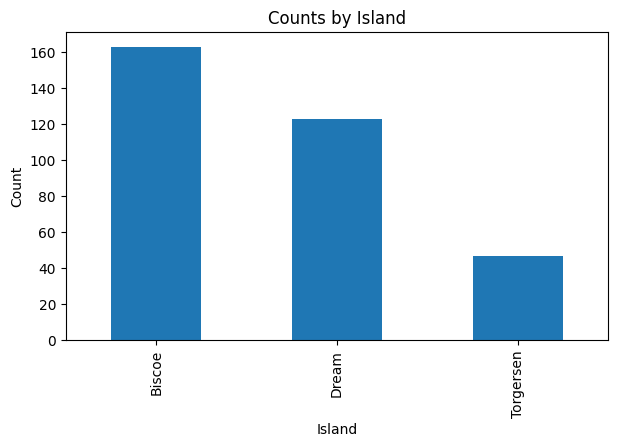

In [8]:
# Where are the Penguins From?
locations = penguins_clean["island"].value_counts()

plt.figure(
    figsize=(7,4)
)

locations.plot(
    kind="bar"
)

plt.title("Counts by Island")
plt.ylabel("Count")
plt.xlabel("Island")

Counting the Penguins by Island reveal some bias in the data.

Torgersen has a fewer penguins in the dataset compared to the other two islands.

If we were to predict where the penguins are from based on their features, the model may under perform when presented with Torgersen Penguins.

## Are Location and Size Related?

<Axes: xlabel='island', ylabel='body_mass_g'>

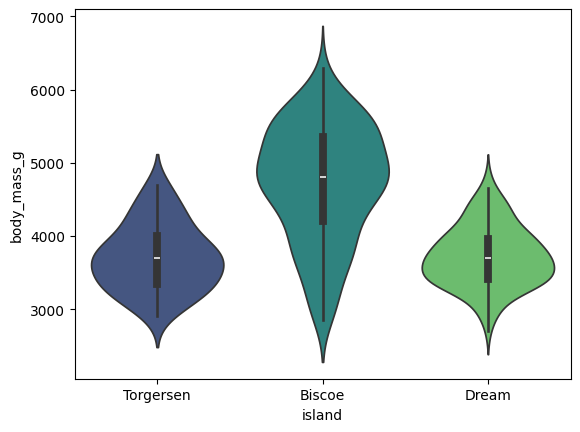

In [9]:
# Body Mass by Island

sns.violinplot(
    data=penguins_clean,
    x="island",
    y="body_mass_g",
    hue="island",
    palette="viridis"
)

When looking at the mass of the Penguins by Island, something's up with Biscoe. These penguins have a larger range of body mass. This may be worth investigating on a scientific level.

## How do the various species compare to one another?

Let's take a look at the Physical Stats of each species compared to one another.

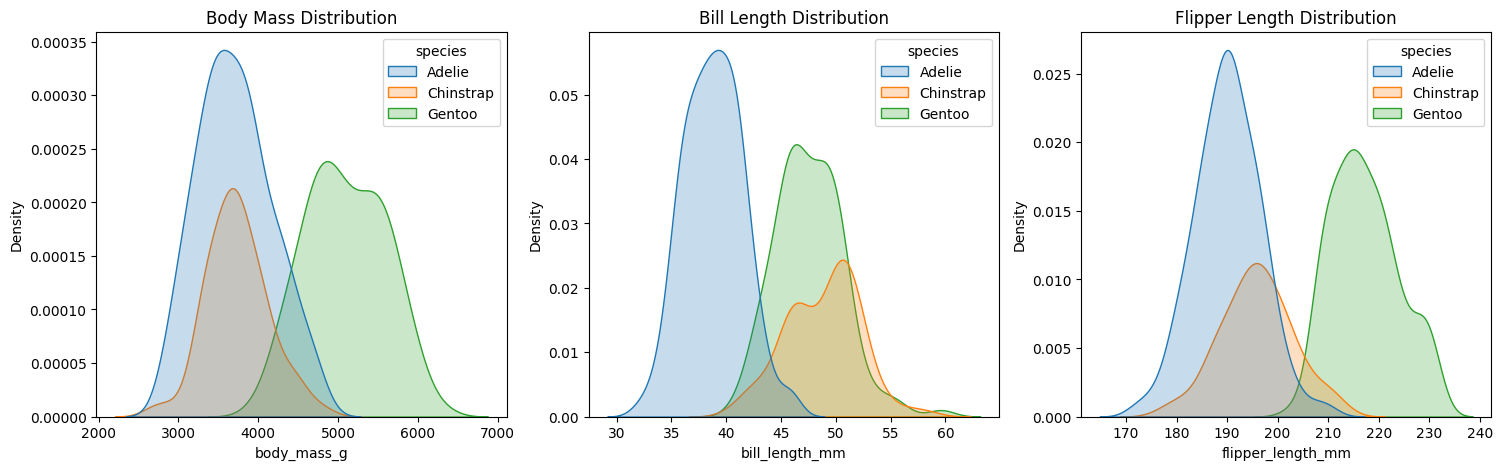

In [10]:
## Species Comparison

# Set up a figure with 1 row and 3 columns
fig, axes = plt.subplots(1,3, figsize=(18,5))

# Plot 1: Body Mass
sns.kdeplot(
    data=penguins_clean,
    x="body_mass_g",
    hue="species",
    fill=True,
    ax=axes[0]
)

axes[0].set_title("Body Mass Distribution")

# Plot 2: Bill Length
sns.kdeplot(
    data=penguins_clean,
    x="bill_length_mm",
    hue="species",
    fill=True,
    ax=axes[1]
)

axes[1].set_title("Bill Length Distribution")

# Plot 3: Flipper Length
sns.kdeplot(
    data=penguins_clean,
    x="flipper_length_mm",
    hue="species",
    fill=True,
    ax=axes[2]
)

axes[2].set_title("Flipper Length Distribution")

plt.show()

### Various Species: My Unscientific Analysis

What are they feeding the Gentoo?

These penguins seem pretty sturdy!

Body mass, bill length, and flipper length are off the charts.

Chinstraps only match in Bill Length with they and the Adelie have much overlap with one another in body mass and flipper length.

## Building a Model

Let's build a model that will predict the Species of a Penguin based on it's physical attributes.

## Preparing the Data

Let's set up the data for the model.

In [11]:
X = penguins_clean.iloc[:, 2:6]
y = penguins_clean["species"]

print(X.info())
print(" - - - - - " * 10)
print(y.info())

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     333 non-null    float64
 1   bill_depth_mm      333 non-null    float64
 2   flipper_length_mm  333 non-null    float64
 3   body_mass_g        333 non-null    float64
dtypes: float64(4)
memory usage: 21.1 KB
None
 - - - - -  - - - - -  - - - - -  - - - - -  - - - - -  - - - - -  - - - - -  - - - - -  - - - - -  - - - - - 
<class 'pandas.core.series.Series'>
Index: 333 entries, 0 to 343
Series name: species
Non-Null Count  Dtype 
--------------  ----- 
333 non-null    object
dtypes: object(1)
memory usage: 13.3+ KB
None


In [12]:
# Split Data
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(y_train.shape)

(266, 4)
(266,)


## Building and Running the Decision Tree

In [13]:
# Build Model
clf = DecisionTreeClassifier(
    random_state=42
)

In [14]:
# Train Model
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
# Make Predictions
y_predictions = clf.predict(X_test)

## Evaluating the Model - Confusion Matrix

In [16]:
# Confusion Matrix
cm = metrics.confusion_matrix(
    y_test, 
    y_predictions,
    labels=clf.classes_
)

cm

array([[31,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 23]])

Text(0.5, 1.0, 'Penguin Species Confusion Matrix')

<Figure size 600x600 with 0 Axes>

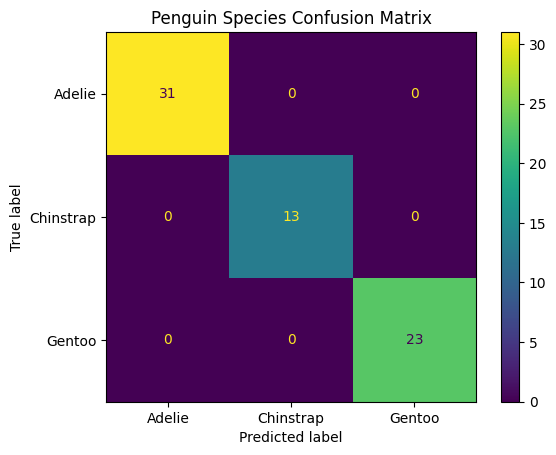

In [17]:
from sklearn import metrics

matrix_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels=clf.classes_
)

plt.figure(figsize=(6,6))

matrix_display.plot()

plt.title("Penguin Species Confusion Matrix")


The Confusion Matrix Reveals that the model has successfully passed the test...but I'm skeptical.

## Classification Report

In [18]:
### Classification Report Results
print(metrics.classification_report(
    y_test, 
    y_predictions, 
    target_names=clf.classes_
)
     )

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        31
   Chinstrap       1.00      1.00      1.00        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



The model performs extremely well with regards to precision, recall, and accuracy 🤔

## Feature Importances

In [19]:
feature_importances = clf.feature_importances_
feature_names = X.columns

penguin_importances_series = pd.Series(
    feature_importances,
    index=feature_names
).sort_values(ascending=False)

penguin_importances_df = penguin_importances_series.reset_index()
penguin_importances_df.columns = ["Feature", "Importance"]

penguin_importances_df

,Feature,Importance
0,flipper_length_mm,0.527933
1,bill_length_mm,0.362951
2,bill_depth_mm,0.093396
3,body_mass_g,0.015720


Text(0.5, 0, 'Importance')

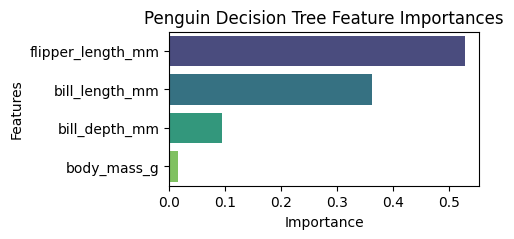

In [20]:
plt.figure(
    figsize=(4,2)
)

sns.barplot(
    data=penguin_importances_df,
    y="Feature",
    x="Importance",
    palette="viridis",
    hue="Feature"
)

plt.title("Penguin Decision Tree Feature Importances")
plt.ylabel("Features")
plt.xlabel("Importance")


It turns out that that flipper and bill length are the top two features in guessing the species. I assumed bodymass would be the most important feature.

## Why is the Model getting 1's?

Let's investigate the top 3 Feature Importances

Text(0.5, 1.0, 'Bill Length vs Bill Depth')

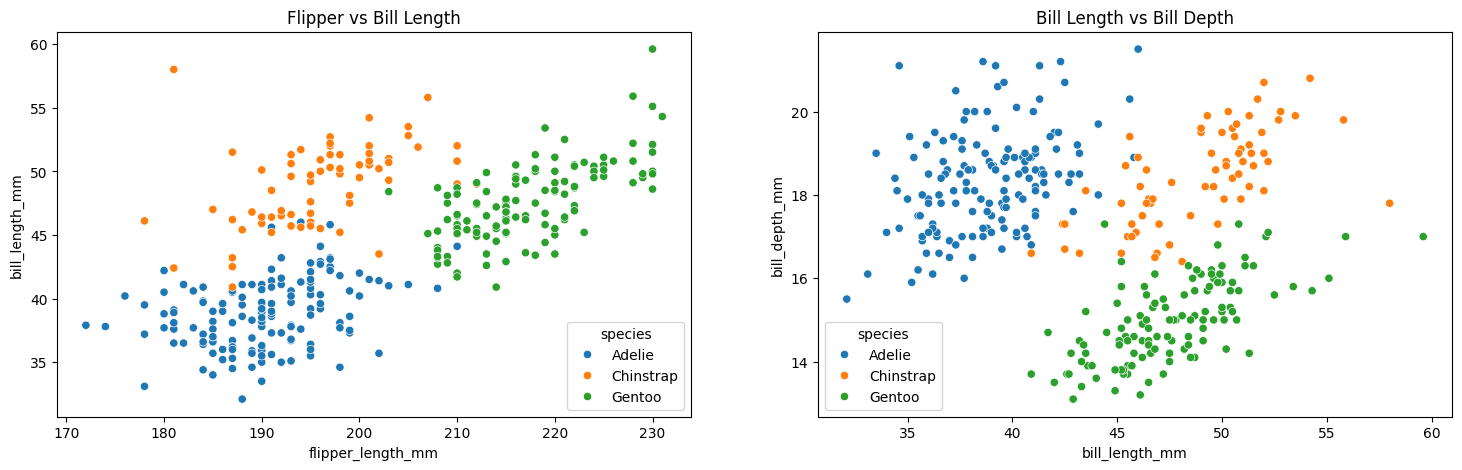

In [21]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18,5)
)

sns.scatterplot(
    data=penguins_clean, 
    x="flipper_length_mm", 
    y="bill_length_mm", 
    hue="species",
    ax=axes[0]
)
axes[0].set_title("Flipper vs Bill Length")

sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    ax=axes[1]
)
axes[1].set_title("Bill Length vs Bill Depth")


When plotting the top 3 features by species there are very clear separations between each species of penguins.

## Exporting the Model

It's time to export the model to build an APP.

In [22]:
import joblib

joblib.dump(
    clf, 
    "penguin_model.joblib"
)

['penguin_model.joblib']